Ridge Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
# loading the pre-defined Boston Dataset
boston_dataset = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/boston.csv')


In [4]:
boston_dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [7]:
# Load the dataset and divide into X and Y variables

boston_pd = boston_dataset.rename(columns={'MEDV': 'House Price'})
X = boston_pd.iloc[:,:-1]

Y = boston_pd.iloc[:,-1]

print(boston_pd.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  House Price  
0     15.3  396.90   4.98         24.0  
1     17.8  396.90   9.14         21.6  
2     17.8  392.83   4.03         34.7  
3     18.7  394.63   2.94         33.4  
4     18.7  396.90   5.33         36.2  


In [8]:
X


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [11]:
x_train , x_test ,y_train ,y_test = train_test_split(boston_pd.iloc[:,:-1] ,boston_pd.iloc[:,-1],test_size = 0.25)
(x_train.shape , x_test.shape ,y_train.shape ,y_test.shape)

((379, 13), (127, 13), (379,), (127,))

In [17]:
# applying multiple linear regression model
lreg = LinearRegression()
lreg.fit(x_train ,y_train)

# generate prediction on test set
lreg_y_pred = lreg.predict(x_test)

# claculating mean square error(MSE)
mean_squared_error = np.mean((lreg_y_pred - y_test)**2)
print("Mean Squared Error on test set : ",mean_squared_error)

# putting together the coefficients and there corrsponding variable names
lreg_coefficient = pd.DataFrame()
lreg_coefficient["columns"] = x_train.columns
lreg_coefficient['coefficient Estimate'] = pd.Series(lreg.coef_)
print(lreg_coefficient)

Mean Squared Error on test set :  26.3107281994852
    columns  coefficient Estimate
0      CRIM             -0.121484
1        ZN              0.056197
2     INDUS              0.048914
3      CHAS              2.292968
4       NOX            -17.829307
5        RM              3.459836
6       AGE              0.018060
7       DIS             -1.276879
8       RAD              0.300066
9       TAX             -0.010723
10  PTRATIO             -0.956797
11        B              0.008935
12    LSTAT             -0.552168


<Axes: xlabel='coefficient Estimate', ylabel='columns'>

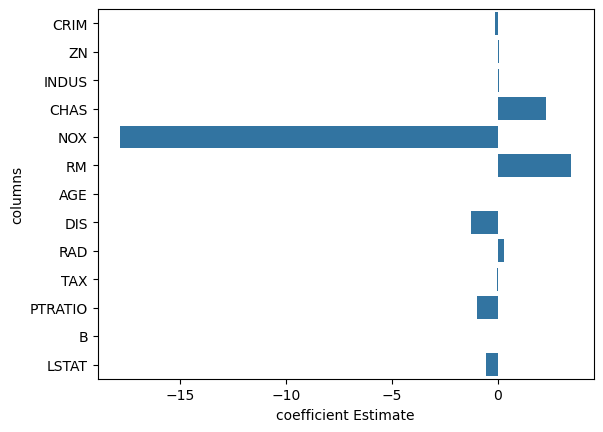

In [18]:
import seaborn as sns
sns.barplot(x ='coefficient Estimate' , y = 'columns' , data = lreg_coefficient)

In [24]:
# import ridge regression form sklearn library
from sklearn.linear_model import Ridge

# train the model
ridgeR = Ridge(alpha =1)
ridgeR.fit(x_train , y_train)
y_pred = ridgeR.predict(x_test)

# caluclate mean squared error
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print(mean_squared_error_ridge)

# get ridge coefficeint and print them
ridge_coefficient = pd.DataFrame()
ridge_coefficient['Columns'] = x_train.columns
ridge_coefficient['coefficient Estimated'] = pd.Series(ridgeR.coef_)
print(ridge_coefficient)

26.48952853025012
    Columns  coefficient Estimated
0      CRIM              -0.117637
1        ZN               0.057636
2     INDUS               0.010966
3      CHAS               2.232256
4       NOX              -9.479097
5        RM               3.529191
6       AGE               0.009839
7       DIS              -1.161298
8       RAD               0.282306
9       TAX              -0.011505
10  PTRATIO              -0.860089
11        B               0.009373
12    LSTAT              -0.558842


<Axes: xlabel='coefficient Estimated', ylabel='Columns'>

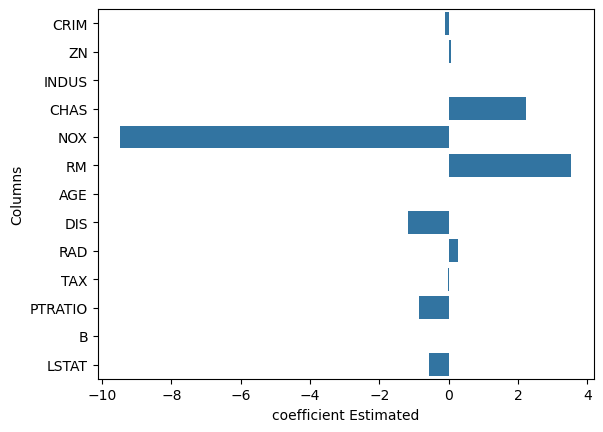

In [26]:
sns.barplot(x ='coefficient Estimated' , y = 'Columns' , data = ridge_coefficient)

In [29]:
# importing lasso regression from sklearn library
from sklearn.linear_model import Lasso

# train the model
lasso = Lasso(alpha =.2)
lasso.fit(x_train , y_train)
y_pred1 = lasso.predict(x_test)

# caluclate mean squared error
mean_squared_error_lasso= np.mean((y_pred1 - y_test)**2)
print(mean_squared_error_lasso)

# get ridge coefficeint and print them
lasso_coefficient = pd.DataFrame()
lasso_coefficient['Columns'] = x_train.columns
lasso_coefficient['coefficient Estimated'] = pd.Series(lasso.coef_)
print(lasso_coefficient)

28.75898512006093
    Columns  coefficient Estimated
0      CRIM              -0.109739
1        ZN               0.060689
2     INDUS              -0.000113
3      CHAS               0.000000
4       NOX              -0.000000
5        RM               3.146463
6       AGE               0.009210
7       DIS              -0.914126
8       RAD               0.279907
9       TAX              -0.013946
10  PTRATIO              -0.756003
11        B               0.010014
12    LSTAT              -0.602906


In [33]:
# importing ElasticNet regression from sklearn library
from sklearn.linear_model import ElasticNet

# train the model
e_net = ElasticNet(alpha =.4,l1_ratio=.5)
e_net.fit(x_train , y_train)
y_pred2 = e_net.predict(x_test)

# caluclate mean squared error
mean_squared_error_e_net= np.mean((y_pred2 - y_test)**2)
print(mean_squared_error_e_net)

# get ridge coefficeint and print them
e_net_coefficient = pd.DataFrame()
e_net_coefficient['Columns'] = x_train.columns
e_net_coefficient['coefficient Estimated'] = pd.Series(e_net.coef_)
e_net_coefficient

30.93018341319291


,Columns,coefficient Estimated
0,CRIM,-0.108488
1,ZN,0.066429
2,INDUS,-0.007969
3,CHAS,0.000000
4,NOX,-0.000000
5,RM,1.822077
6,AGE,0.021959
7,DIS,-0.848788
8,RAD,0.309864
9,TAX,-0.015072
